# Surface Heat Flux

In [1]:
# packages for data processing
import numpy as np
import pandas as pd
import xarray as xr
from xmitgcm import open_mdsdataset
import gsw as gsw

# packages for plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go # interactive/3D plotting
import plotly.express as px
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from plotting_functions import *

# technical packages
import warnings

## Load Surface Diagnostics 

In [2]:
model_run = "MSL005"
delta_t = 4 # time step in seconsurfDiag
output_dir = "../../MITgcm/so_plumes/" + model_run

# surpress the xmitgcm warning about future changes with timedelta
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    # open dataset
    surfDiag = open_mdsdataset(output_dir, prefix = ['surfDiag'], delta_t = delta_t, geometry = "cartesian")

## Heat Fluxes

- TFLUX: "total heat flux (match heat-content variations), >0 increases theta" -> this corresponds to the actual change in temperature
- surForcT: "model surface forcing for Temperature, >0 increases theta" -> what we set as forcing
- oceQnet: "net surface heat flux into the ocean (+=down), >0 increases theta" -> looks like oceQnet = surfForcT in our setting

Difference between surForcT and TFLUX corresponds to heat loss that would drive into ice formation.






## Surface Animation

In [3]:
# TFLUX
surface_animation(surfDiag, var='TFLUX', model_run=model_run, time_dim='time', x_dim='XC', y_dim='YC', colorscale="thermal")

### Surface Snapshot

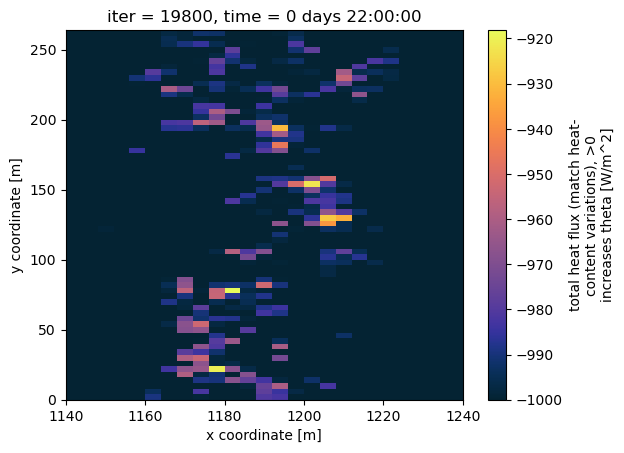

In [ ]:
t = surfDiag.time[10]#
xmin = 1142 # needs to be a multiple of 4 +2
xmax = 1238 # needs to be a multiple of 4 +2
surfDiag.TFLUX.sel(time=t, XC=slice(xmin, xmax)).plot(x="XC", y="YC", cmap=cmo.thermal)

## Line Plot

Text(0.5, 1.0, 'Lead-averaged surface heat flux over time')

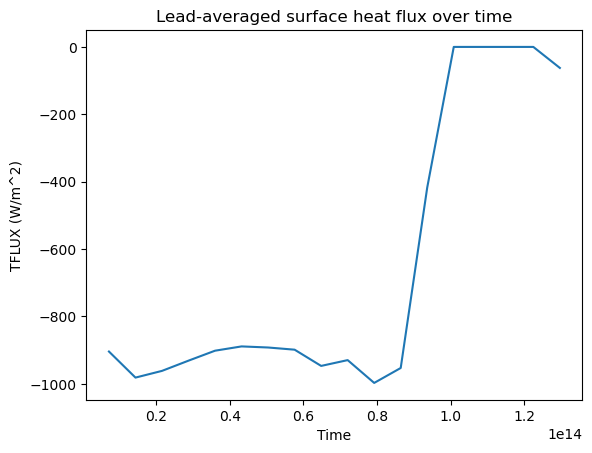

In [52]:
# lead-spatially averaged TFLUX over time
TFLUX_lead = surfDiag.TFLUX.sel(XC=slice(1142, 1238))
TFLUX_lead.mean(dim = ["XC", "YC"]).plot(x="time")
plt.ylabel("TFLUX (W/m^2)")
plt.title("Lead-averaged surface heat flux over time")